In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


day_df = pd.read_csv("/content/drive/MyDrive/day.csv")


Mounted at /content/drive


In [ ]:
print(day_df.columns)


Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')


In [ ]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

In [ ]:
day_df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [ ]:
day_df[['casual','registered']].skew()



,0
casual,1.266454
registered,0.043659


In [ ]:
#feature generation
day_df['year'] = day_df['dteday'].dt.year
day_df['month'] = day_df['dteday'].dt.month
day_df['day'] = day_df['dteday'].dt.day
day_df['is_weekend'] = day_df['weekday'].apply(lambda x: 1 if x in [5,6] else 0)



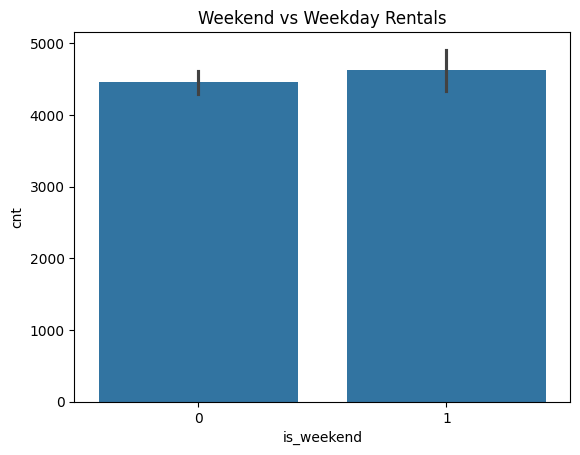

In [ ]:
sns.barplot(x='is_weekend', y='cnt', data=day_df)
plt.title("Weekend vs Weekday Rentals")
plt.show()


In [ ]:
day_df.head()


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,year,month,day,is_weekend
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,2011,1,1,1
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,2011,1,2,0
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,2011,1,3,0
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,2011,1,4,0
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,2011,1,5,0


In [ ]:
#feature interaction
day_df['weather_index'] = day_df['temp'] + day_df['hum'] + day_df['windspeed']

In [ ]:
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,...,hum,windspeed,casual,registered,cnt,year,month,day,is_weekend,weather_index
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,...,0.805833,0.160446,331,654,985,2011,1,1,1,1.310446
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,...,0.696087,0.248539,131,670,801,2011,1,2,0,1.308104
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,...,0.437273,0.248309,120,1229,1349,2011,1,3,0,0.881946
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,...,0.590435,0.160296,108,1454,1562,2011,1,4,0,0.950731
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,...,0.436957,0.186900,82,1518,1600,2011,1,5,0,0.850814


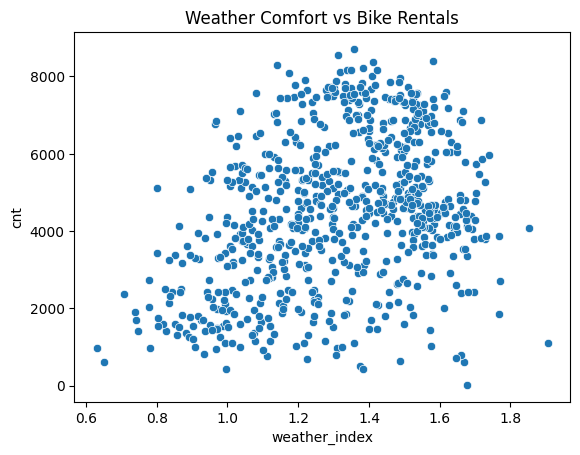

In [ ]:
sns.scatterplot(x='weather_index', y='cnt', data=day_df)
plt.title("Weather Comfort vs Bike Rentals")
plt.show()


In [ ]:
#one-hot encoding
X_day = pd.get_dummies(
    X_day,
    columns=cat_cols_day,
    drop_first=True
)


In [ ]:
y_day = day_df['cnt']


In [ ]:
X_day = day_df.drop(columns=[
    'cnt',        # target
    'dteday'      # raw date not useful for models
])

In [ ]:
cat_cols_day = ['season', 'weathersit', 'weekday']


In [ ]:
X_day.shape, y_day.shape


((731, 27), (731,))

In [ ]:
X_day.head()

,instant,yr,mnth,holiday,workingday,temp,atemp,hum,windspeed,casual,...,season_3,season_4,weathersit_2,weathersit_3,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6
0,1,0,1,0,0,0.344167,0.363625,0.805833,0.160446,331,...,False,False,True,False,False,False,False,False,False,True
1,2,0,1,0,0,0.363478,0.353739,0.696087,0.248539,131,...,False,False,True,False,False,False,False,False,False,False
2,3,0,1,0,1,0.196364,0.189405,0.437273,0.248309,120,...,False,False,False,False,True,False,False,False,False,False
3,4,0,1,0,1,0.200000,0.212122,0.590435,0.160296,108,...,False,False,False,False,False,True,False,False,False,False
4,5,0,1,0,1,0.226957,0.229270,0.436957,0.186900,82,...,False,False,False,False,False,False,True,False,False,False


In [ ]:
y_day.head()

,cnt
0,985
1,801
2,1349
3,1562
4,1600
